## Análisis Descriptivo Multivariable

Referencias: 
- [Applied multivariate statistics](https://rich-d-wilkinson.github.io/MATH3030/part-ii-dimension-reduction-methods.html)

El análisis descriptivo multivariable implica la exploración y el análisis de múltiples variables para entender las interrelaciones y cómo estas influyen en las decisiones empresariales. Este tipo de análisis es fundamental para comprender los contextos en los que operan los KPIs y cómo diferentes factores se influyen mutuamente.

### Técnicas de Clustering

**¿Qué es el Clustering?**
El clustering es una técnica de aprendizaje automático no supervisado que agrupa un conjunto de objetos de tal manera que los objetos en el mismo grupo (o cluster) son más similares entre sí que con los de otros grupos. Es ampliamente utilizado para la segmentación de datos en diferentes grupos.

**¿Cuándo se utiliza?**
El clustering se emplea para explorar la estructura de los datos, para resumirlos en grupos manejables, o como una etapa de procesamiento previo para otros algoritmos. Es común en análisis de mercados, organización de computadoras en redes, clasificación de genes en biología, y en cualquier área que requiera una segmentación del conjunto de datos.

**Beneficios del Clustering:**
- **Descubrimiento de patrones:** Identifica agrupaciones y patrones desconocidos en conjuntos de datos.
- **Segmentación útil:** Facilita la segmentación de la base de clientes, productos o cualquier otra entidad analítica en grupos distintos para estrategias de targeting más específicas.
- **Optimización de recursos:** Permite la asignación eficiente de recursos al identificar y categorizar grupos con características similares.


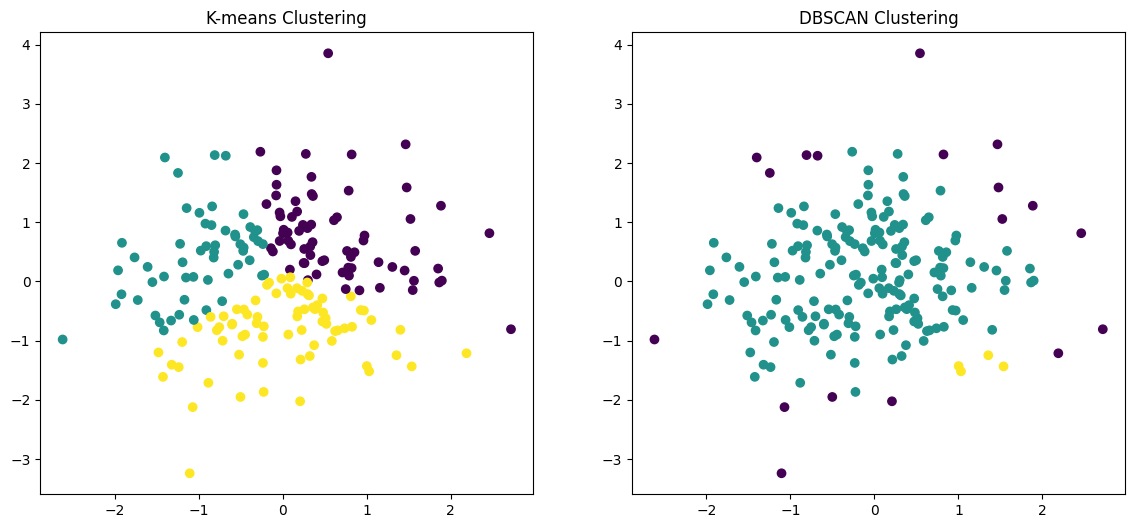

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
data = pd.DataFrame({
    'Feature1': np.random.randn(200),
    'Feature2': np.random.randn(200)
})

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# K-means clustering
kmeans = KMeans(n_clusters=3)
kmeans_labels = kmeans.fit_predict(scaled_data)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

# Plotting the clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# K-means plot
ax1.scatter(data['Feature1'], data['Feature2'], c=kmeans_labels, cmap='viridis')
ax1.set_title('K-means Clustering')

# DBSCAN plot
ax2.scatter(data['Feature1'], data['Feature2'], c=dbscan_labels, cmap='viridis')
ax2.set_title('DBSCAN Clustering')

plt.show()

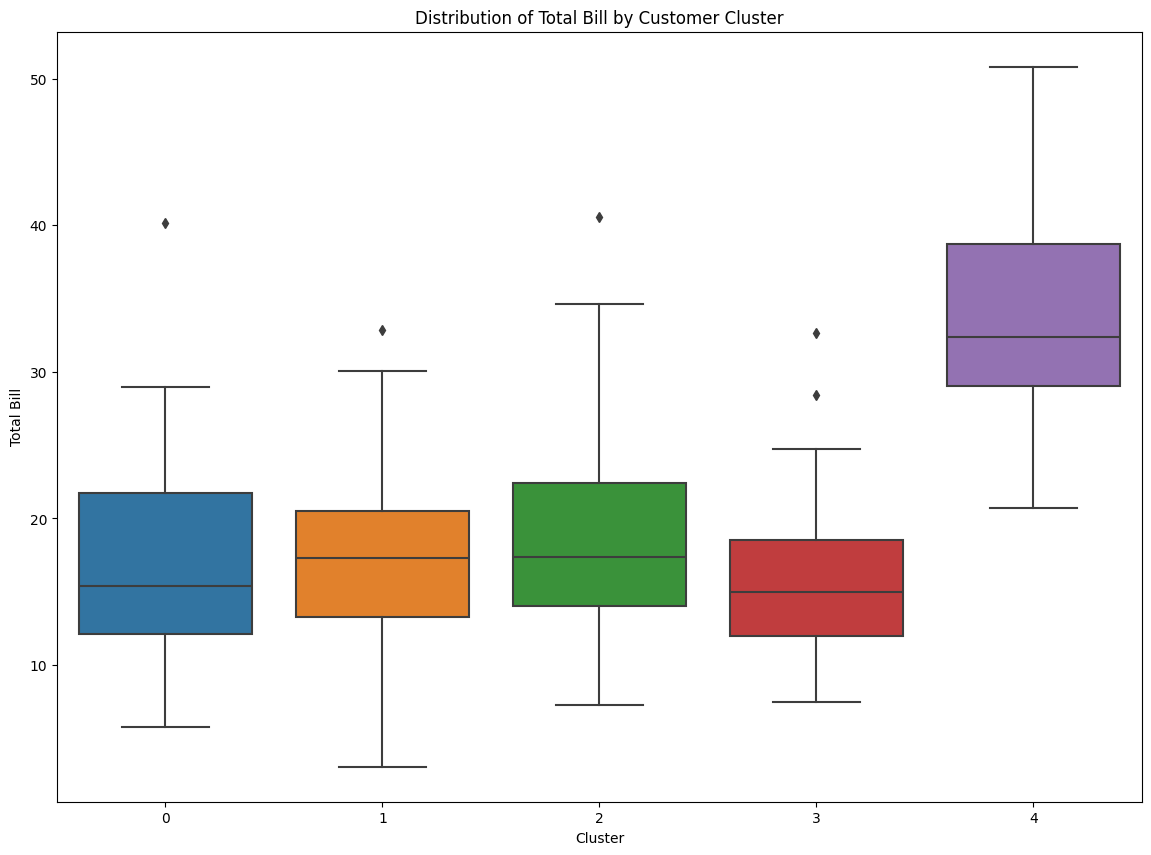

In [2]:
# Importar librerías necesarias
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(working_memory=1024)

# Cargar el conjunto de datos 'tips' de Seaborn
data = sns.load_dataset('tips')

# Convertir variables categóricas en variables dummies
categorical_features = ['sex', 'smoker', 'day', 'time']
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Preparar los datos seleccionando características relevantes y normalizándolos
features = ['total_bill', 'tip', 'size'] + list(data_encoded.columns[5:])  # Incluir características categóricas codificadas
x = data_encoded.loc[:, features].values
x = StandardScaler().fit_transform(x)  # Normalización de las características

# Aplicar K-means clustering para identificar segmentos de clientes
kmeans = KMeans(n_clusters=5, random_state=42) 
labels = kmeans.fit_predict(x)

# Agregar las etiquetas del cluster al DataFrame original para análisis
data_encoded['Cluster'] = labels

# Visualizar los resultados del clustering
plt.figure(figsize=(14, 10))

# Create a boxplot to visualize the distribution of 'total_bill' for each 'Cluster'
sns.boxplot(x='Cluster', y='total_bill', data=data_encoded)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('Total Bill')
plt.title('Distribution of Total Bill by Customer Cluster')

# Display the plot
plt.show()


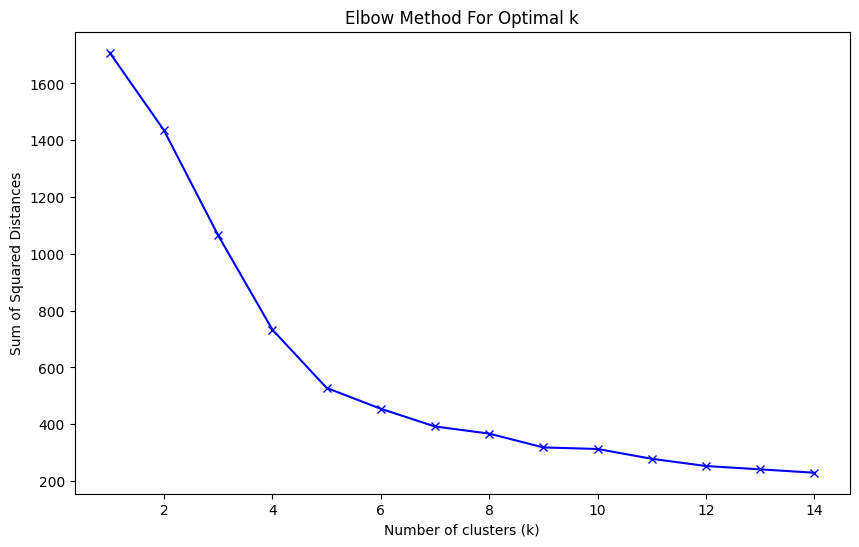

In [3]:
# Determinar el número óptimo de clusters usando el método del codo
sum_of_squared_distances = []
K = range(1, 15)  # Ajuste el rango según sea necesario
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km = km.fit(x)
    sum_of_squared_distances.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

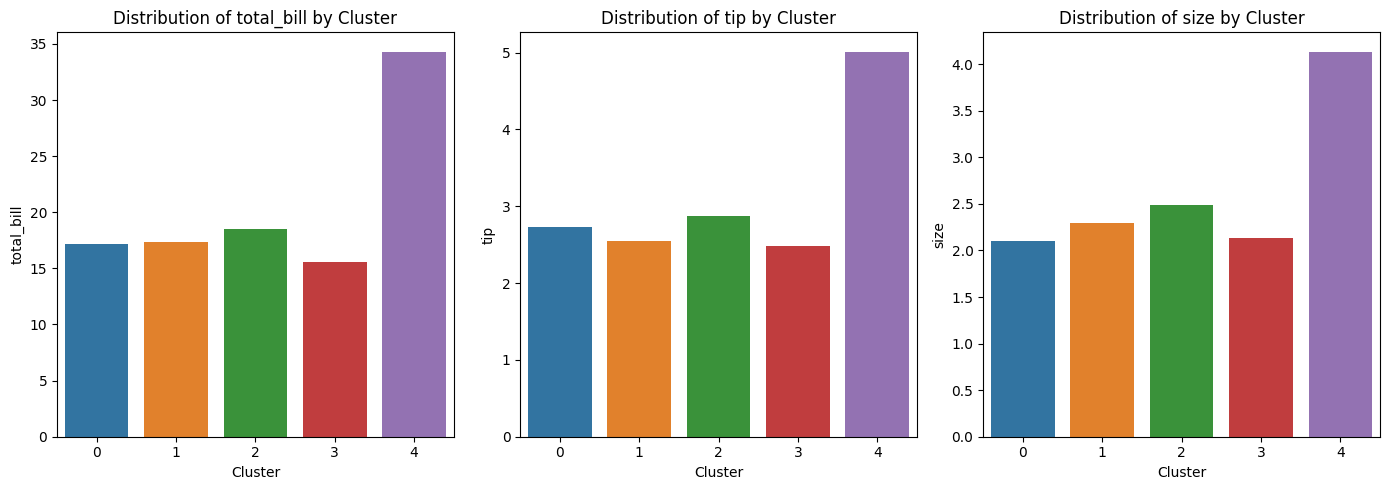

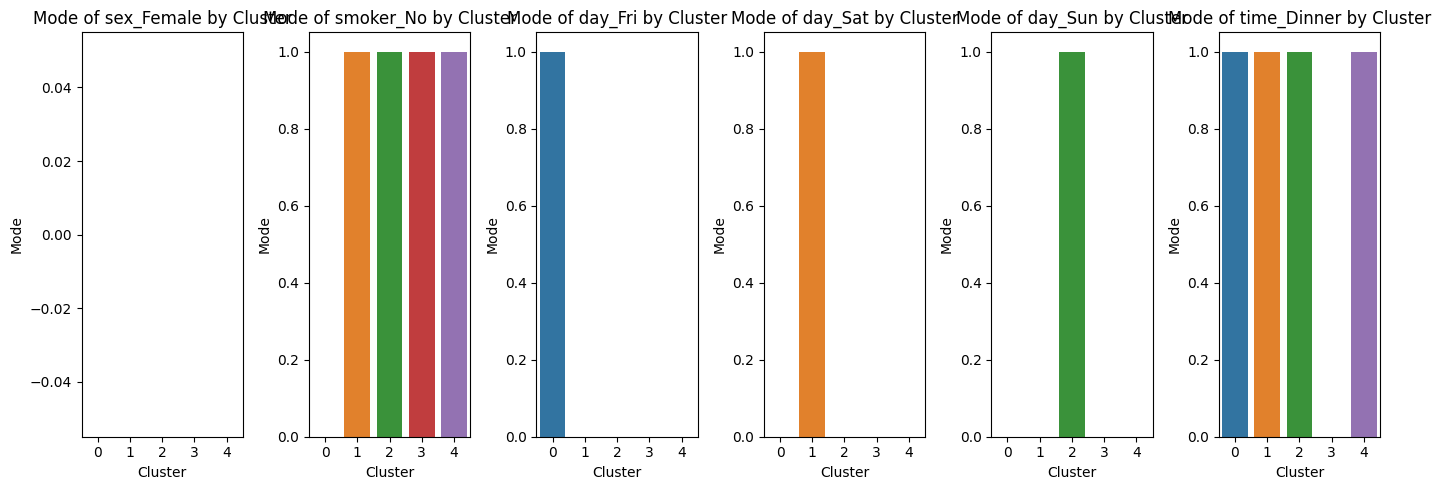

In [4]:
# Define a function to summarize the cluster characteristics
def summarize_clusters(data):
    # Numerical features
    numerical_features = ['total_bill', 'tip', 'size']  # Modify this list based on your dataset
    # Categorical features (assuming dummy variables were created)
    categorical_features = [col for col in data.columns if col.startswith('sex_') or col.startswith('smoker_') or col.startswith('day_') or col.startswith('time_')]

    # Summary DataFrame for numerical features
    cluster_summary_numerical = data.groupby('Cluster')[numerical_features].mean()
    
    # Summary DataFrame for categorical features
    cluster_summary_categorical = data.groupby('Cluster')[categorical_features].agg(lambda x: x.value_counts().index[0])

    return cluster_summary_numerical, cluster_summary_categorical

# Generate the summary for each cluster
cluster_summary_numerical, cluster_summary_categorical = summarize_clusters(data_encoded)

# Plotting
def plot_cluster_summary(cluster_summary_numerical, cluster_summary_categorical):
    # Plot numerical summaries
    fig, axes = plt.subplots(nrows=1, ncols=len(cluster_summary_numerical.columns), figsize=(14, 5))
    for i, col in enumerate(cluster_summary_numerical.columns):
        sns.barplot(x=cluster_summary_numerical.index, y=col, data=cluster_summary_numerical, ax=axes[i])
        axes[i].set_title(f'Distribution of {col} by Cluster')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    # Plot categorical summaries
    fig, axes = plt.subplots(nrows=1, ncols=len(cluster_summary_categorical.columns), figsize=(14, 5))
    for i, col in enumerate(cluster_summary_categorical.columns):
        sns.barplot(x=cluster_summary_categorical.index, y=col, data=cluster_summary_categorical, ax=axes[i])
        axes[i].set_title(f'Mode of {col} by Cluster')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Mode')

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_cluster_summary(cluster_summary_numerical, cluster_summary_categorical)